## Panda practice
### Dataset: Disney

#### Step 1: Project director role

##### Variables (only examples):
- Title
- Release date
- Genre
- Director
- Ratings
- Awards
- Languages
- Runtime

##### High-level questions the data could answer:
1. Which directors/genres win the most awards per movie, and does awards count relate to rating?
2. Do critic scores (metascores) and audience scores (IMDb) agree, and for which movies do they differ most?
3. Does release month/season correlate with movie success?
4. Does the average rating of a director increase over time?

#### Step 2: Project manager role
Question: Does release month/season correlate with movie success?
- What measures do we choose (IMDb rating, Metascore, combination, awards)?
  - Success: IMDb rating only, because it is available for most movies
- Which date (release/added date) defines the month/season?
  - Date: release date, because date added reflects the platform, not the movie
- Calendar months only or grouped (e.g. winter/spring/summer/fall)?
  - Seasons: winter/spring/summer/autumn, because 12 months gives too few movies per group
- Do we drop missing values or fill them in? Which variables are affected?
  - Drop movies without an IMDb rating or release date
- Weight IMDb by number of votes, or not?
  - Yes (by IMDb votes), because movies with more voters should count more in each season's average.

Core variables: release date, season, IMDB rating, IMDb votes

#### Step 3: Data analyst role
##### Size:
- 992 rows
- 19 columns
- 98 rows have no imdb_id (look like empty rows)
  - Missing values in core variables are mostly those same rows
  - Real dataset has about 894 titles
##### released_at:
- Stored as text, format DD-MM-YY
  - Conversion to datetime needed (explicit format, century fix: YY above 20 means 19YY, otherwise 20YY)
- Missing values are stored as "N/A"
- 20 titles missing
  - 118 blanks, including empty rows
- Range: 1929-2020
##### imdb_rating:
- Numeric
- Missing values are stored as "N/A"
- 15 titles missing
- Range: 1.5-9.7, no odd values
##### imdb_votes:
- Saved as number/text
  - Conversion to numeric needed (remove commas if present)
- Missing values are stored as "N/A"
- 15 titles missing
  - in the same rows as missing ratings
- Range: 5-1'225'316
  - Median: ~3'950
##### Rows left after dropping missing values:
864 of the 894 titles
##### type column:
- Mixes movies, series and episodes
  - 673 movies, 173 series, 18 episodes among the 864
  - Keep only movies
##### Few votes:
- 248 of the 864 titles have fewer than 1'000 votes, 74 have fewer than 100
  - Weighting by votes handles this, but still worth to note it

##### Draft analysis plan
1. Drop completely empty rows (no imdb_id)
2. Treat "N/A" as missing in released_at, imdb_rating and imdb_votes
3. Convert imdb_votes to numeric (remove commas if present)
4. Convert released_at to datetime with an explicit day-month-year format (fix the century: YY above 20 means 19YY, otherwise 20YY; check against the year column)
5. Keep only type == "movie" (series and episodes are most likely not comparable to movies)
6. Drop rows with missing released_at, imdb_rating or imdb_votes
7. Create month from released_at, then season: December-February: winter, March-May: spring, June-August: summer, September-November: autumn
8. Create weighted rating contribution: imdb_rating * imdb_votes
9. Group by season: weighted mean = sum(imdb_rating*imdb_votes)/sum(imdb_votes)
   - Also count movies per season (as a sample-size check)
10. Compare seasons
   - Output: table with season, number of movies and weighted mean IMDb rating, then bar chart

#### Step 4: Back-and-forth between roles
##### Feasibility:
- Question can be answered with this data
  - 673 movies remain after cleaning (680 movies before dropping missing values)
  - About 170 movies per season on average (check the exact split per season)
- Key variables (release date, IMDb rating, IMDb votes) are missing for only about 3% of titles
  - No need for additional data
##### Time estimate:
- Cleaning (N/A, votes to numeric, empty rows, movies only): ~30 minutes
- Date conversion (DD-MM-YY, century fix): ~1 hour
  - Riskiest step, because two-digit years go back to 1929
- Season variable: ~15 minutes
- Weighted mean per season: ~30 minutes
- Table and bar chart: ~30 minutes
- Total: ~3 hours
##### Message to the project director:
- I can deliver a table and bar chart with the vote-weighted mean IMDb rating per season (winter, spring, summer, autumn) for Disney movies
- Assumptions: movies only (no series or episodes), release date (not date added), IMDb rating only, weighted by number of votes, movies with missing rating, votes or release date dropped
- Limitations: many movies have few votes (248 of 864 titles have fewer than 1'000 votes), and the century of two-digit years has to be inferred
  - The result shows a correlation only, not a causal effect of the release season
##### Possible cheap add-ons:
- Same analysis per month instead of season
- Same analysis per decade
- Unweighted mean as a robustness check

In [2]:
import pandas as pd #import pandas

df = pd.read_excel("Disney_raw.xlsx", na_values="N/A") #read file into a DataFrame

In [3]:
df.shape

(992, 19)

In [4]:
df.head()

,imdb_id,title,plot,type,rated,year,released_at,added_at,runtime,genre,director,writer,actors,language,country,awards,metascore,imdb_rating,imdb_votes
0,tt0147800,10 Things I Hate About You,"A pretty, popular teenager can't go out on a d...",movie,PG-13,1999,1999-03-31,2019-11-12,97 min,"Comedy, Drama, Romance",Gil Junger,"Karen McCullah, Kirsten Smith","Heath Ledger, Julia Stiles, Joseph Gordon-Levi...","English, French",USA,2 wins & 13 nominations.,70.0,7.3,283945.0
1,tt7019028,101 Dalmatian Street,This series follows the lives of Delilah and D...,series,NaN,2018‚Äì,2019-03-25,2020-02-28,NaN,"Animation, Comedy, Family",NaN,NaN,"Josh Brener, Michaela Dietz, Bert Davis, Abiga...",English,"UK, USA, Canada",NaN,NaN,6.2,124.0
2,tt0115433,101 Dalmatians,An evil high-fashion designer plots to steal D...,movie,G,1996,1996-11-27,2019-11-12,103 min,"Adventure, Comedy, Crime, Family",Stephen Herek,"Dodie Smith (novel), John Hughes (screenplay)","Glenn Close, Jeff Daniels, Joely Richardson, J...","English, Spanish","USA, UK",Nominated for 1 Golden Globe. Another 3 wins &...,49.0,5.7,97785.0
3,tt0324941,101 Dalmatians 2: Patch's London Adventure,"Being one of 101 takes its toll on Patch, who ...",movie,G,2002,2003-01-21,2019-11-12,74 min,"Animation, Adventure, Comedy, Family, Musical","Jim Kammerud, Brian Smith","Jim Kammerud (story), Dan Root (story), Garret...","Barry Bostwick, Jason Alexander, Martin Short,...",English,USA,5 wins & 10 nominations.,NaN,5.8,7434.0
4,tt0211181,102 Dalmatians,Cruella DeVil gets out of prison and goes afte...,movie,G,2000,2000-11-22,2019-11-12,100 min,"Adventure, Comedy, Family",Kevin Lima,"Dodie Smith (novel), Kristen Buckley (story), ...","Glenn Close, G√©rard Depardieu, Ioan Gruffudd,...",English,"USA, UK",Nominated for 1 Oscar. Another 1 win & 7 nomin...,35.0,4.9,33444.0


In [5]:
df.dtypes

imdb_id                object
title                  object
plot                   object
type                   object
rated                  object
year                   object
released_at    datetime64[ns]
added_at       datetime64[ns]
runtime                object
genre                  object
director               object
writer                 object
actors                 object
language               object
country                object
awards                 object
metascore             float64
imdb_rating           float64
imdb_votes            float64
dtype: object

In [6]:
# 1. Drop completely empty rows (no imdb_id)
df = df.dropna(subset=["imdb_id"])

In [9]:
# 2. Convert votes and rating to numeric (remove comas if present)
df["imdb_votes"] = pd.to_numeric(df["imdb_votes"].astype(str).str.replace(",", ""), errors="coerce")
df["imdb_rating"] = pd.to_numeric(df["imdb_rating"], errors="coerce")

In [10]:
# 3. Convert votes and rating to numeric (+ remove comas if present)
df["released_at"] = pd.to_datetime(df["released_at"], format="%d-%m-%y", errors="coerce")

In [12]:
# 4. Century fix: pandas reads YY of 00-68 as 20YY, but data ends in 2020
mask = df["released_at"].dt.year > 2020
df.loc[mask, "released_at"] = df.loc[mask, "released_at"] - pd.DateOffset(years=100)

In [13]:
#check Output
print(df.shape)
print(df[["released_at", "imdb_rating", "imdb_votes"]].dtypes)
print(df["released_at"].min(), df["released_at"].max())
print(df[["released_at", "imdb_rating", "imdb_votes"]].isna().sum())

(894, 19)
released_at    datetime64[ns]
imdb_rating           float64
imdb_votes            float64
dtype: object
1929-01-01 00:00:00 2020-04-10 00:00:00
released_at    20
imdb_rating    15
imdb_votes     15
dtype: int64


In [14]:
# Checkpoint 3: Movies only, drop missing values
# Keep only movies
df = df[df["type"] == "movie"]
print(df.shape)

# Drop rows with missing released_at, imdb_rating or imdb_votes
df = df.dropna(subset=["released_at", "imdb_rating", "imdb_votes"])
print(df.shape)

(680, 19)
(673, 19)


In [15]:
# Checkpoint 4: create month and season
# Month (1-12) from the release date
df["month"] = df["released_at"].dt.month

# Season from month
def get_season(m):
    if m in [12, 1, 2]:
        return "winter"
    elif m in [3, 4, 5]:
        return "spring"
    elif m in [6, 7, 8]:
        return "summer"
    else:
        return "autumn"

df["season"] = df["month"].apply(get_season)

In [16]:
# check output
print(df["season"].value_counts())
print(df[["released_at", "month", "season"]].head())

season
summer    195
autumn    162
winter    161
spring    155
Name: count, dtype: int64
  released_at  month  season
0  1999-03-31      3  spring
2  1996-11-27     11  autumn
3  2003-01-21      1  winter
4  2000-11-22     11  autumn
5  2011-12-11     12  winter


In [17]:
# Checkpoint 5: weighted mean and movie count per season
# Weighted rating contribution (plan step 8)
df["weighted"] = df["imdb_rating"] * df["imdb_votes"]

# Aggregate per season
result = df.groupby("season").agg(
    n_movies=("title", "count"),
    sum_weighted=("weighted", "sum"),
    sum_votes=("imdb_votes", "sum"),
    mean_rating=("imdb_rating", "mean"),   # unweighted, for the robustness check
)

# Weighted mean = sum(rating * votes) / sum(votes)
result["weighted_mean_rating"] = result["sum_weighted"] / result["sum_votes"]

# Put seasons in calendar order
result = result.loc[["winter", "spring", "summer", "autumn"]]
result[["n_movies", "weighted_mean_rating", "mean_rating"]]

,n_movies,weighted_mean_rating,mean_rating
season,,,
winter,161,7.168570,6.457764
spring,155,7.471650,6.589032
summer,195,7.503795,6.481026
autumn,162,7.523045,6.806173


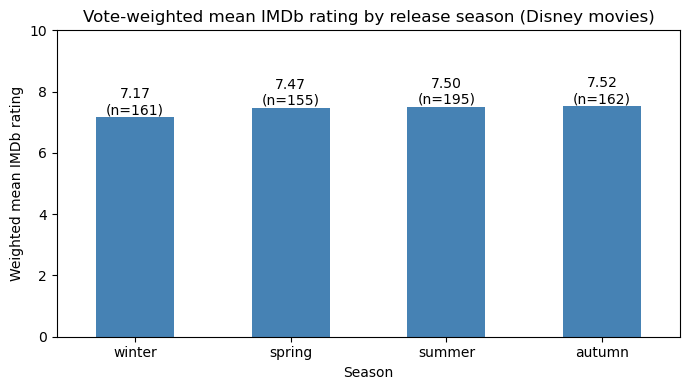

In [18]:
# Checkpoint 6: bar chart
import matplotlib.pyplot as plt

ax = result["weighted_mean_rating"].plot(kind="bar", color="steelblue", figsize=(7, 4))
ax.set_title("Vote-weighted mean IMDb rating by release season (Disney movies)")
ax.set_xlabel("Season")
ax.set_ylabel("Weighted mean IMDb rating")
ax.set_ylim(0, 10)
ax.set_xticklabels(result.index, rotation=0)

# Show the number of movies on each bar
for i, (w, n) in enumerate(zip(result["weighted_mean_rating"], result["n_movies"])):
    ax.text(i, w + 0.1, f"{w:.2f}\n(n={n})", ha="center")

plt.tight_layout()
plt.show()